# CRN-SVM


## Setup
This block imports the numerical and plotting packages used throughout the notebook.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from scipy.integrate import solve_ivp


## Data And Parallel Reference Utilities
This block defines dataset generation, feature standardization, the divisor-corrected batch schedule, and the Python reference update that mirrors the parallel CRN schedule.


In [2]:
def make_linearly_separable_2d(n_per_class=8, center_sep=5.0, noise_std=0.6, seed=1):
    """Generate a random-orientation linearly separable 2D dataset."""
    rng = np.random.default_rng(seed)
    angle = rng.uniform(0.0, 2.0 * np.pi)
    d = np.array([np.cos(angle), np.sin(angle)])
    c_pos = 0.5 * center_sep * d
    c_neg = -0.5 * center_sep * d
    X_pos = c_pos + rng.normal(0.0, noise_std, size=(n_per_class, 2))
    X_neg = c_neg + rng.normal(0.0, noise_std, size=(n_per_class, 2))
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])
    idx = rng.permutation(len(y))
    return X[idx], y[idx]


def train_test_split(X, y, test_frac=0.25, seed=1):
    """Random train/test split with deterministic seed."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    n_test = int(round(test_frac * len(y)))
    te, tr = idx[:n_test], idx[n_test:]
    return X[tr], y[tr], X[te], y[te]


def standardize_fit(X):
    """Compute mean/std for feature standardization."""
    mu = X.mean(axis=0)
    sig = X.std(axis=0)
    sig = np.where(sig == 0, 1.0, sig)
    return mu, sig


def standardize_apply(X, mu, sig):
    """Apply z-score standardization using fitted mean/std."""
    return (X - mu) / sig


@dataclass(frozen=True)
class BatchSchedule:
    """Equal-size block schedule induced by the requested batch size.

    Attributes
    ----------
    n_samples:
        Number of training samples.
    requested_batch_size:
        User-provided batch size.
    effective_batch_size:
        Largest divisor of `n_samples` not exceeding `requested_batch_size`.
    active_lanes:
        Number of parallel chemical lanes. This equals `effective_batch_size`.
    n_blocks:
        Number of equal-size blocks per epoch.
    lane_lists:
        Strided sample allocation for each lane.
    """
    n_samples: int
    requested_batch_size: int
    effective_batch_size: int
    active_lanes: int
    n_blocks: int
    lane_lists: tuple[tuple[int, ...], ...]


def build_batch_schedule(n_samples: int, requested_batch_size: int, verbose: bool = False, prefix: str = '[batch]') -> BatchSchedule:
    """Build the divisor-corrected batch schedule used by both Python and CRN paths.

    The parallel loader assumes all blocks have the same size. If the requested
    batch size does not divide the sample count, the schedule falls back to the
    closest smaller divisor and reports that choice when `verbose=True`.
    """
    n_samples = max(1, int(n_samples))
    requested = max(1, min(int(requested_batch_size), n_samples))
    if n_samples % requested == 0:
        effective = requested
    else:
        effective = max(d for d in range(1, requested + 1) if n_samples % d == 0)
        if verbose:
            print(f"{prefix} batch_size={requested_batch_size} does not divide n_samples={n_samples}; defaulting to batch_size={effective}")
    lane_lists = tuple(tuple(range(lane, n_samples, effective)) for lane in range(effective))
    return BatchSchedule(
        n_samples=n_samples,
        requested_batch_size=requested,
        effective_batch_size=effective,
        active_lanes=effective,
        n_blocks=n_samples // effective,
        lane_lists=lane_lists,
    )


def run_python_parallel_lane_baseline_epochs(
    X,
    y,
    eta=0.2,
    lam=0.1,
    epochs=4,
    batch_size=2,
    schedule: BatchSchedule | None = None,
    seed=1,
    shuffle=False,
):
    """Run the mean-minibatch Python reference aligned with the parallel CRN schedule.

    One Python update is performed per block, not per sample. The gradient is
    averaged over the effective batch size so it matches the CRN update slot.
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape
    schedule = build_batch_schedule(n, batch_size) if schedule is None else schedule
    if schedule.n_samples != n:
        raise ValueError('schedule.n_samples must match X.shape[0]')

    block_size = schedule.effective_batch_size
    n_blocks = schedule.n_blocks
    alpha = 1.0 - eta * lam
    w = np.zeros(d, dtype=float)
    b = 0.0
    W_hist = [w.copy()]
    b_hist = [b]
    hinge_frac = []
    for _ in range(epochs):
        idx = rng.permutation(n) if shuffle else np.arange(n)
        X_epoch = X[idx]
        y_epoch = y[idx]
        hcnt = 0
        for blk in range(n_blocks):
            lo = blk * block_size
            hi = lo + block_size
            grad = np.zeros(d, dtype=float)
            db = 0.0
            for j in range(lo, hi):
                margin = float(y_epoch[j] * (w @ X_epoch[j] + b))
                hinge = int(margin < 1.0)
                hcnt += hinge
                if hinge == 1:
                    grad += y_epoch[j] * X_epoch[j]
                    db += y_epoch[j]
            w = alpha * w + (eta / block_size) * grad
            b = b + (eta / block_size) * db
        W_hist.append(w.copy())
        b_hist.append(float(b))
        hinge_frac.append(hcnt / n)
    return np.vstack(W_hist), np.array(b_hist), np.array(hinge_frac)


def predict_linear(X, w, b):
    """Binary prediction from linear score sign."""
    return np.where(X @ w + b >= 0.0, 1.0, -1.0)


def accuracy(X, y, w, b):
    """Classification accuracy helper."""
    return float(np.mean(predict_linear(X, w, b) == y))


## CRN Engine
This block defines the reaction data model and the compiled mass-action evaluator used by both the oscillator and the SVM network.


In [3]:
@dataclass(frozen=True)
class Reaction:
    """Single mass-action reaction entry.

    Parameters
    ----------
    reactants : Dict[str, int]
        Reactant stoichiometry (species -> exponent/order).
    products : Dict[str, int]
        Product stoichiometry (species -> count).
    k : float
        Reaction rate constant.
    oscillator : Optional[int]
        Oscillator channel index. When this is ``None``, the compiled CRN stores
        the sentinel value ``-1`` to denote an always-on reaction. During RHS
        evaluation, only nonnegative oscillator indices scale the reaction rate by
        the corresponding entry of the oscillator vector.
    """
    reactants: Dict[str, int]
    products: Dict[str, int]
    k: float
    oscillator: Optional[int] = None


class MassActionCRN:
    """Compiled mass-action CRN with optional oscillator-indexed reactions.

    The compiler stores stoichiometric deltas and reactant lookup tables once so
    repeated RHS evaluations during ODE integration only assemble reaction fluxes
    and multiply them by the precomputed stoichiometric matrix.
    """

    def __init__(self, species: List[str], reactions: List[Reaction]):
        """Initialize and compile CRN structure for fast RHS evaluation."""
        self.species = list(species)
        self.reactions = list(reactions)
        self.s_index = {s: i for i, s in enumerate(self.species)}
        self._compile()

    def _compile(self):
        """Compile stoichiometry and reactant lookup arrays used in rhs()."""
        m = len(self.species)
        r = len(self.reactions)
        self._delta = np.zeros((r, m), dtype=float)
        self._ks = np.zeros(r, dtype=float)
        # `-1` is the sentinel for reactions that are not tied to any oscillator
        # channel. Those reactions remain active regardless of the current
        # oscillator state and therefore bypass oscillator-based rate scaling.
        # In this notebook, that case is used by the Hopf clock subnetwork, which
        # must evolve continuously while driving the oscillator-indexed SVM reactions.
        self._oscillators = np.full(r, -1, dtype=int)
        self._react_idx = []
        self._react_pow = []

        for j, rxn in enumerate(self.reactions):
            # Store scalar rate constant for reaction j.
            self._ks[j] = float(rxn.k)
            # Reactions with an explicit oscillator index are scaled later by the
            # corresponding oscillator channel. Reactions left at `-1` are always
            # on and are unaffected by the oscillator vector.
            if rxn.oscillator is not None:
                self._oscillators[j] = int(rxn.oscillator)
            # Stoichiometric net change vector for reaction j.
            for sp, nu in rxn.reactants.items():
                self._delta[j, self.s_index[sp]] -= float(nu)
            for sp, nu in rxn.products.items():
                self._delta[j, self.s_index[sp]] += float(nu)

            # Precompute reactant indices/powers for fast mass-action monomial evaluation.
            idxs, pows = [], []
            for sp, nu in rxn.reactants.items():
                idxs.append(self.s_index[sp])
                pows.append(int(nu))
            self._react_idx.append(np.array(idxs, dtype=int))
            self._react_pow.append(np.array(pows, dtype=int))

    def rhs(self, y: np.ndarray, oscillator_vec: np.ndarray):
        """Return species derivatives and reaction fluxes for state ``y``.

        Each reaction flux is the mass-action monomial associated with its
        reactants, scaled by the reaction constant and, when present, by the
        currently active oscillator weight.
        """
        r = len(self.reactions)
        v = np.zeros(r, dtype=float)

        for j in range(r):
            rate = self._ks[j]
            g = self._oscillators[j]
            # Only reactions assigned to a nonnegative oscillator channel are
            # modulated by the current oscillator vector. In this notebook, the
            # Hopf-clock reactions are the always-on exception, whereas the SVM
            # reactions are tied to specific oscillator channels.
            if g >= 0:
                # A one-hot oscillator vector leaves the selected channel at full
                # strength and suppresses the others to zero for that phase.
                rate *= float(oscillator_vec[g])

            idxs = self._react_idx[j]
            pows = self._react_pow[j]
            if idxs.size == 0:
                v[j] = rate
            else:
                term = 1.0
                for ii, nu in zip(idxs, pows):
                    term *= y[ii] ** nu
                v[j] = rate * term

        dy = v @ self._delta
        return dy, v


## Hopf Clock And Oscillator Readout (Implementing Oscillator Module)
This section defines the oscillator-driven scheduler used in the notebook. The clock is encoded in dual rail by the nonnegative species `H_Xp, H_Xn, H_Zp, H_Zn`, which are decoded into signed coordinates `x = H_Xp - H_Xn` and `z = H_Zp - H_Zn`.

The decoded dynamics follow the Hopf normal form
- `x_dot = (mu - x^2 - z^2) x - omega z`
- `z_dot = (mu - x^2 - z^2) z + omega x`

For `mu > 0`, the decoded state converges to a limit cycle. The phase `theta = atan2(z, x) mod 2*pi` is discretized into `n_clock` bins, yielding a one-hot oscillator vector with exact peak value `1.0` for the active oscillator.


In [4]:
@dataclass(frozen=True)
class HopfClockParams:
    """Parameters controlling the dual-rail Hopf clock.

    Attributes
    ----------
    n_clock : int
        Number of oscillator channels in one full control cycle.
    mu : float
        Radial growth parameter of the Hopf normal form. The stable orbit has
        radius approximately ``sqrt(mu)`` when ``mu > 0``.
    omega : float
        Angular frequency in radians per unit time.
    kappa : float
        Compatibility parameter retained in the notebook configuration interface.
    eps : float
        Small numerical guard used when initializing or decoding the clock state.
    """
    n_clock: int = 12
    mu: float = 1.0
    omega: float = 2*np.pi/114.0
    kappa: float = 25.0
    eps: float = 1e-15


def hopf_make_params(n_clock: int, phase_duration: float, mu: float = 1.0, kappa: float = 25.0):
    """Construct Hopf-clock parameters from the requested oscillator timing.

    The oscillator period is matched to ``n_clock * phase_duration`` so one full
    orbit corresponds to one traversal of the oscillator schedule.
    """
    period = float(n_clock) * float(phase_duration)
    return HopfClockParams(n_clock=n_clock, mu=mu, omega=2*np.pi/period, kappa=kappa)


def hopf_phase(y: np.ndarray):
    """Return the wrapped oscillator phase in ``[0, 2*pi)`` for decoded state ``[x, z]``."""
    th = np.arctan2(float(y[1]), float(y[0]))
    return th + 2*np.pi if th < 0 else th


def decode_clock_dualrail(y_clock_dr: np.ndarray):
    """Decode the dual-rail clock species into the signed state ``[x, z]``."""
    x = float(y_clock_dr[0] - y_clock_dr[1])
    z = float(y_clock_dr[2] - y_clock_dr[3])
    return np.array([x, z], dtype=float)


def init_clock_dualrail_phase0(params: HopfClockParams, eps: float = 1e-9):
    """Initialize the dual-rail Hopf species near phase zero on the limit cycle.

    A small offset is placed on the opposite rails so the initial state is not
    exactly singular in either rail pair.
    """
    r = float(np.sqrt(max(params.mu, 1e-12)))
    return np.array([r, eps, eps, eps], dtype=float)


def build_dualrail_hopf_clock_crn(params: HopfClockParams, k_ann: float = 80.0, rate_scale: float = 1.0):
    """Build the dual-rail mass-action Hopf oscillator subnetwork.

    Decoded state representation
    ----------------------------
    x = H_Xp - H_Xn,    z = H_Zp - H_Zn.

    Target Hopf dynamics
    --------------------
    x' = (mu - x^2 - z^2)x - omega z
    z' = (mu - x^2 - z^2)z + omega x

    Equivalent polynomial form used for reaction compilation
    --------------------------------------------------------
    x' = mu*x - x^3 - x*z^2 - omega*z
    z' = mu*z - z^3 - z*x^2 + omega*x

    Reaction-network form (mass-action motifs)
    ------------------------------------------
    For each signed monomial term c*x^a*z^b:
    1) Expand x=(H_Xp-H_Xn), z=(H_Zp-H_Zn) by binomial identities.
    2) For each expanded nonzero term, create a catalytic production reaction:
         reactants -> reactants + H_Xp   (if contribution to x' is positive)
         reactants -> reactants + H_Xn   (if contribution to x' is negative)
         reactants -> reactants + H_Zp   (if contribution to z' is positive)
         reactants -> reactants + H_Zn   (if contribution to z' is negative)
       with rate |c_term|.
    3) Add rail-annihilation stabilization:
         H_Xp + H_Xn -> ∅
         H_Zp + H_Zn -> ∅

    Final Reaction Network
    ----------------------
    Linear growth terms:
        H_Xp                  --mu-->     2 H_Xp
        H_Xn                  --mu-->     2 H_Xn
        H_Zp                  --mu-->     2 H_Zp
        H_Zn                  --mu-->     2 H_Zn

    Self-saturation terms for -x^3:
        3 H_Xn                --1-->      3 H_Xn + H_Xp
        H_Xp + 2 H_Xn         --3-->      H_Xp + 3 H_Xn
        2 H_Xp + H_Xn         --3-->      3 H_Xp + H_Xn
        3 H_Xp                --1-->      3 H_Xp + H_Xn

    Self-saturation terms for -z^3:
        3 H_Zn                --1-->      3 H_Zn + H_Zp
        H_Zp + 2 H_Zn         --3-->      H_Zp + 3 H_Zn
        2 H_Zp + H_Zn         --3-->      3 H_Zp + H_Zn
        3 H_Zp                --1-->      3 H_Zp + H_Zn

    Cross-saturation terms for -x*z^2:
        H_Xn + 2 H_Zn         --1-->      H_Xn + 2 H_Zn + H_Xp
        H_Xn + H_Zp + H_Zn    --2-->      2 H_Xn + H_Zp + H_Zn
        H_Xn + 2 H_Zp         --1-->      H_Xn + 2 H_Zp + H_Xp
        H_Xp + 2 H_Zn         --1-->      H_Xp + 2 H_Zn + H_Xn
        H_Xp + H_Zp + H_Zn    --2-->      2 H_Xp + H_Zp + H_Zn
        H_Xp + 2 H_Zp         --1-->      H_Xp + 2 H_Zp + H_Xn

    Cross-saturation terms for -z*x^2:
        2 H_Xn + H_Zn         --1-->      2 H_Xn + H_Zn + H_Zp
        2 H_Xn + H_Zp         --1-->      2 H_Xn + H_Zp + H_Zn
        H_Xp + H_Xn + H_Zn    --2-->      H_Xp + H_Xn + 2 H_Zn
        H_Xp + H_Xn + H_Zp    --2-->      H_Xp + H_Xn + 2 H_Zp
        2 H_Xp + H_Zn         --1-->      2 H_Xp + H_Zn + H_Zp
        2 H_Xp + H_Zp         --1-->      2 H_Xp + H_Zp + H_Zn

    Rotational coupling terms for -omega*z and +omega*x:
        H_Zn                  --omega-->  H_Zn + H_Xp
        H_Zp                  --omega-->  H_Zp + H_Xn
        H_Xn                  --omega-->  H_Xn + H_Zn
        H_Xp                  --omega-->  H_Xp + H_Zp

    Rail-annihilation stabilization:
        H_Xp + H_Xn           --k_ann-->  ∅
        H_Zp + H_Zn           --k_ann-->  ∅

    Gating association
    ------------------
    During training, this clock CRN is merged with the SVM CRN. The decoded phase
    theta = atan2(z, x) is mapped to a phase bin to activate one oscillator channel.
    """
    from math import comb

    species = ['H_Xp', 'H_Xn', 'H_Zp', 'H_Zn']
    rxns: List[Reaction] = []

    # Each polynomial term is stored as (coefficient, power_of_x, power_of_z).
    dx_terms = [
        (params.mu, 1, 0),
        (-1.0, 3, 0),
        (-1.0, 1, 2),
        (-params.omega, 0, 1),
    ]
    dz_terms = [
        (params.mu, 0, 1),
        (-1.0, 0, 3),
        (-1.0, 2, 1),
        (params.omega, 1, 0),
    ]

    def add_signed_poly_to_dualrail(target_pos: str, target_neg: str, terms):
        """Compile signed polynomial terms into dual-rail production reactions.

        For each monomial c * x^a * z^b, expand x=(Xp-Xn), z=(Zp-Zn)
        using binomial coefficients. Each expanded term contributes a nonnegative
        mass-action reaction whose product rail is chosen by the sign of the term:
          positive term -> target_pos production
          negative term -> target_neg production
        """
        for base_coef, x_pow, z_pow in terms:
            for ix in range(x_pow + 1):
                cx = comb(x_pow, ix) * ((-1) ** (x_pow - ix))
                xp_pow = ix
                xn_pow = x_pow - ix
                for iz in range(z_pow + 1):
                    cz = comb(z_pow, iz) * ((-1) ** (z_pow - iz))
                    zp_pow = iz
                    zn_pow = z_pow - iz

                    coef = float(base_coef * cx * cz) * float(rate_scale)
                    if abs(coef) < 1e-15:
                        continue

                    reactants = {}
                    if xp_pow > 0:
                        reactants['H_Xp'] = int(xp_pow)
                    if xn_pow > 0:
                        reactants['H_Xn'] = int(xn_pow)
                    if zp_pow > 0:
                        reactants['H_Zp'] = int(zp_pow)
                    if zn_pow > 0:
                        reactants['H_Zn'] = int(zn_pow)

                    products = dict(reactants)
                    out = target_pos if coef > 0 else target_neg
                    products[out] = products.get(out, 0) + 1

                    rxns.append(Reaction(reactants, products, k=abs(coef), oscillator=None))

    add_signed_poly_to_dualrail('H_Xp', 'H_Xn', dx_terms)
    add_signed_poly_to_dualrail('H_Zp', 'H_Zn', dz_terms)

    # Opposite-rail annihilation keeps the signed decoding well conditioned.
    rxns.append(Reaction({'H_Xp': 1, 'H_Xn': 1}, {}, k=float(k_ann), oscillator=None))
    rxns.append(Reaction({'H_Zp': 1, 'H_Zn': 1}, {}, k=float(k_ann), oscillator=None))

    return MassActionCRN(species, rxns)


## Optional Standalone Hopf Demo
This block simulates the Hopf clock in isolation and visualizes the decoded state, the phase trajectory, the active slot index, and the one-hot oscillator channels.


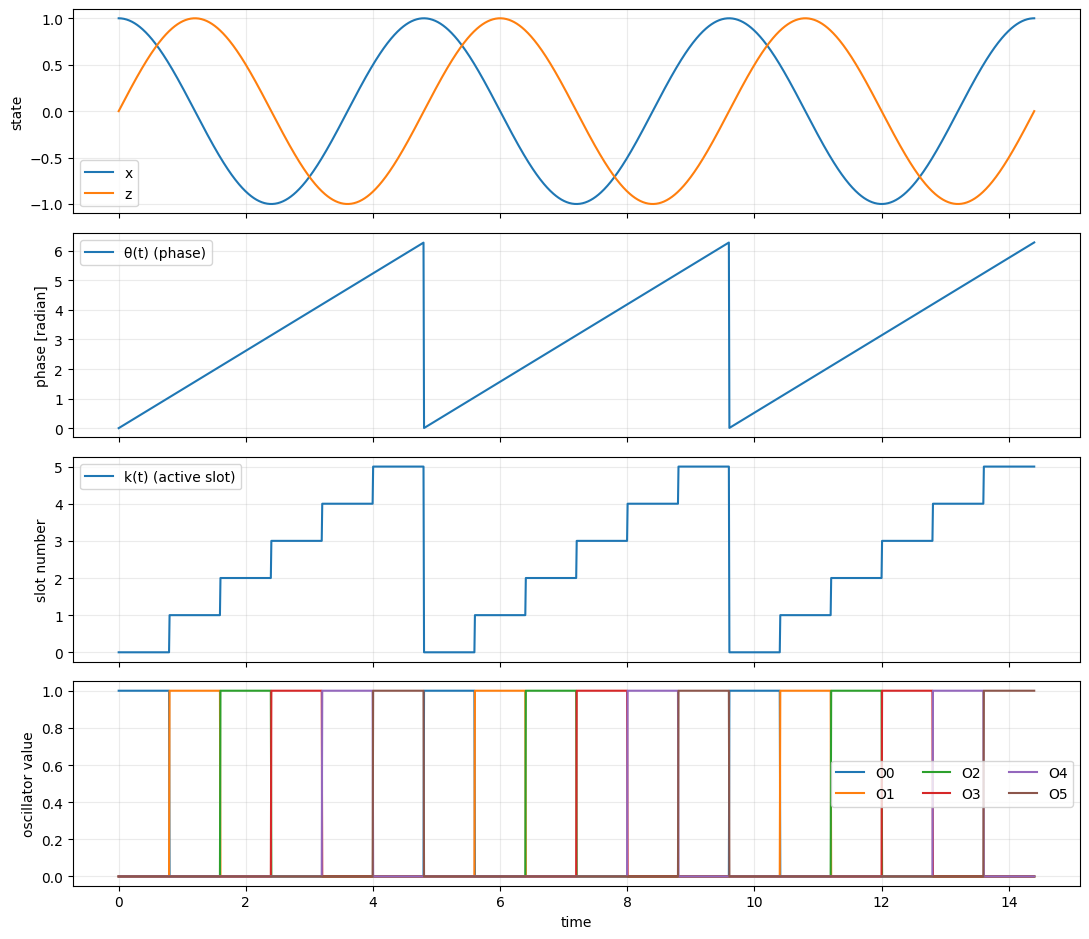

max oscillator peak=1.0000


In [5]:
RUN_HOPF_STANDALONE_DEMO = True

if RUN_HOPF_STANDALONE_DEMO:
    n_clock_demo = 6
    phase_duration_demo = 0.8
    p_demo = hopf_make_params(n_clock_demo, phase_duration_demo, mu=1.0, kappa=300.0)
    hopf_demo_crn = build_dualrail_hopf_clock_crn(p_demo, k_ann=80.0, rate_scale=1.0)
    y0_demo = init_clock_dualrail_phase0(p_demo)

    T = 3 * n_clock_demo * phase_duration_demo
    t_eval = np.linspace(0.0, T, max(1400, int(120 * T)))
    sol = solve_ivp(
        lambda t, y: hopf_demo_crn.rhs(y, np.zeros(1, dtype=float))[0],
        (0.0, T),
        y0_demo,
        t_eval=t_eval,
        method='RK23',
        rtol=1e-4,
        atol=1e-7,
        max_step=max(0.002, phase_duration_demo / 12.0),
    )
    if sol.status != 0:
        raise RuntimeError(f'Hopf standalone demo failed: {sol.message}')

    t_h = sol.t
    Y_h = sol.y
    x_dec = Y_h[0, :] - Y_h[1, :]
    z_dec = Y_h[2, :] - Y_h[3, :]

    phase = np.array([hopf_phase(np.array([x_dec[k], z_dec[k]])) for k in range(t_h.size)])
    active_slot = np.array([int(np.floor((phase[k] / (2*np.pi)) * n_clock_demo)) % n_clock_demo for k in range(t_h.size)], dtype=int)
    O = np.zeros((n_clock_demo, t_h.size), dtype=float)
    O[active_slot, np.arange(t_h.size)] = 1.0
    oscillator_peak = np.max(O, axis=0)

    fig, ax = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True)
    ax[0].plot(t_h, x_dec, label='x')
    ax[0].plot(t_h, z_dec, label='z')
    ax[0].set_ylabel('state')
    ax[0].grid(alpha=0.25)
    ax[0].legend()

    ax[1].plot(t_h, phase, label='θ(t) (phase)')
    ax[1].set_ylabel('phase [radian]')
    ax[1].grid(alpha=0.25)
    ax[1].legend()

    ax[2].plot(t_h, active_slot, label='k(t) (active slot)')
    ax[2].set_ylabel('slot number')
    ax[2].grid(alpha=0.25)
    ax[2].legend()

    for k in range(n_clock_demo):
        ax[3].plot(t_h, O[k, :], label=f'O{k}')
    ax[3].set_ylabel('oscillator value')
    ax[3].set_xlabel('time')
    ax[3].grid(alpha=0.25)
    ax[3].legend(ncol=3)

    plt.tight_layout()
    plt.show()
    print(f'max oscillator peak={float(np.max(oscillator_peak)):.4f}')


## Parallel SVM Reaction Modules
This block defines the dual-rail reaction motifs and assembles the 12-slot parallel-batch CRN. Each lane carries its own active sample and lane-local intermediates, while the parameter rails and paper-style update species are shared across lanes.


In [6]:
# Implements dual rail module
def encode_dualrail(v: float):
    """Encode a signed scalar ``v`` into nonnegative dual-rail concentrations ``(p, n)``."""
    return max(v, 0.0), max(-v, 0.0)


def decode_dualrail(p: float, n: float):
    """Decode a dual-rail pair back to the signed value ``p - n``."""
    return float(p - n)

# Implements multiplication module
def add_mul_nonneg(rxns: List[Reaction], A: str, B: str, P: str, k: float, oscillator: int):
    """Append the oscillator-controlled multiplication surrogate ``A + B -> A + B + P`` with ``P -> ∅``."""
    rxns.append(Reaction({A: 1, B: 1}, {A: 1, B: 1, P: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({P: 1}, {}, k=k, oscillator=oscillator))

# Implements addition module
def add_add_nonneg(rxns: List[Reaction], A: str, B: str, C: str, k: float, oscillator: int):
    """Append the oscillator-controlled addition surrogate ``A -> A + C``, ``B -> B + C``, ``C -> ∅``."""
    rxns.append(Reaction({A: 1}, {A: 1, C: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({B: 1}, {B: 1, C: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({C: 1}, {}, k=k, oscillator=oscillator))

# Implements loading module
def add_copy_nonneg(rxns: List[Reaction], X: str, OUT: str, k: float, oscillator: int):
    """Append the oscillator-controlled copy motif ``X -> X + OUT`` together with ``OUT -> ∅``."""
    rxns.append(Reaction({X: 1}, {X: 1, OUT: 1}, k=k, oscillator=oscillator))
    rxns.append(Reaction({OUT: 1}, {}, k=k, oscillator=oscillator))

# Helper function to append a multiplication (X, SEL) and store them in OUT
def add_masked_prod_nonneg(rxns: List[Reaction], X: str, SEL: str, OUT: str, k: float, oscillator: int):
    """Append the selector-controlled production motif ``X + SEL -> X + SEL + OUT``."""
    rxns.append(Reaction({X: 1, SEL: 1}, {X: 1, SEL: 1, OUT: 1}, k=k, oscillator=oscillator))

# Helper function to append a decay reaction for OUT species
def add_decay_nonneg(rxns: List[Reaction], OUT: str, k: float, oscillator: int):
    """Append oscillator-controlled decay ``OUT -> ∅``."""
    rxns.append(Reaction({OUT: 1}, {}, k=k, oscillator=oscillator))

# Implements the subtraction module
def add_subtraction(rxns: List[Reaction], A: str, B: str, C: str, H: str, k_make: float, k_decay: float, k_ann: float, oscillator: int):
    """Add the nonnegative subtraction network `C ≈ max(A - B, 0)`.

    Active reactions in the selected oscillator:
    - `A -> A + C`
    - `B -> B + H`
    - `C -> ∅`
    - `C + H -> ∅`
    """
    rxns.append(Reaction({A: 1}, {A: 1, C: 1}, k=k_make, oscillator=oscillator))
    rxns.append(Reaction({B: 1}, {B: 1, H: 1}, k=k_make, oscillator=oscillator))
    rxns.append(Reaction({C: 1}, {}, k=k_decay, oscillator=oscillator))
    rxns.append(Reaction({C: 1, H: 1}, {}, k=k_ann, oscillator=oscillator))


def build_main_crn_with_batch_loader(
    X_batch: np.ndarray,
    y_batch: np.ndarray,
    *,
    n_clock: int,
    cfg,
    schedule: BatchSchedule,
):
    """Build the 12-slot parallel-batch CRN for one mean-minibatch update cycle.

    Oscillator schedule
    -------------
    0. O0 load:   `C_i^lane` loads the sparse sample reservoirs `I_1^i`, `I_2^i`, `I_3^i`
                  into the active lane inputs `X_1^lane`, `X_2^lane`, `Y^lane`
    1. O1 handoff:`C_i^lane -> Ctil_i^lane`
    2. O2 shift:  rotate each sparse lane cycle `I_lane` to its next active sample
    3. ff-mul:    parameter-input products
    4. ff-add:    accumulate signed margin rails
    5. ff-y:      multiply by the label rails to obtain `Qp` and `Qn`
    6. sub:       compute `Q = max(Qp - Qn, 0)`
    7. cmp:      compare `Q` with `K` using `KgQ/KlQ`
    8. am:       approximate-majority sharpening on `KgQ/KlQ`
    9. upd:       store the update ingredients `R`, `XY`, `Z`, and `S`
    10. commit:   rebuild persistent parameters from the stored update ingredients
    11. reset:    clear transient species, restore `KgQ/KlQ`, and clear shared update stores
    """
    n_samples = X_batch.shape[0]
    n_slots = 12
    if n_clock != n_slots:
        raise ValueError('parallel batch loader expects 12 oscillator slots')
    if schedule.n_samples != n_samples:
        raise ValueError('schedule.n_samples must match X_batch.shape[0]')

    lanes = schedule.active_lanes
    lane_lists = schedule.lane_lists
    block_scale = cfg.eta / schedule.effective_batch_size

    o_load = 0
    o_hand = 1
    o_shift = 2
    o_mul = 3
    o_add = 4
    o_muly = 5
    o_sub = 6
    o_cmp = 7
    o_am = 8
    o_upd = 9
    o_com = 10
    o_rst = 11

    def L(base: str, lane: int) -> str:
        return f'{base}_l{lane}'

    sample_species = ['I1p', 'I1n', 'I2p', 'I2n', 'I3p', 'I3n']
    lane_active = ['X1p', 'X1n', 'X2p', 'X2n', 'Yp', 'Yn']
    lane_transient = [
        'P1pp', 'P1pn', 'P1np', 'P1nn', 'P2pp', 'P2pn', 'P2np', 'P2nn',
        'T1p', 'T1n', 'T2p', 'T2n', 'Sp', 'Sn', 'Mp', 'Mn', 'Qp', 'Qn',
        'Q', 'QH', 'KgQ', 'KlQ', 'U',
    ]
    lane_reset_seed = ['KgQ0', 'KlQ0']

    rxns: List[Reaction] = []
    species = [
        'One', 'K',
        'W1p', 'W1n', 'W2p', 'W2n', 'Bp', 'Bn',
        'R1p', 'R1n', 'R2p', 'R2n',
        'XY1p', 'XY1n', 'XY2p', 'XY2n',
        'Zp', 'Zn', 'Sbp', 'Sbn',
    ]
    for j in range(n_samples):
        for nm in sample_species:
            species.append(f'{nm}_{j}')
    for lane, samples in enumerate(lane_lists):
        for nm in lane_active + lane_transient + lane_reset_seed:
            species.append(L(nm, lane))
        for j in samples:
            species.extend([f'C{j}_l{lane}', f'Ctil{j}_l{lane}'])
    
    # Implementing the Assignment Module
    # O0: the currently active order species loads one sample reservoir into the lane-local input rails.
    for lane, samples in enumerate(lane_lists):
        for j in samples:
            assign_pairs = [
                ('I1p', 'X1p'), ('I1n', 'X1n'),
                ('I2p', 'X2p'), ('I2n', 'X2n'),
                ('I3p', 'Yp'), ('I3n', 'Yn'),
            ]
            for src, dst in assign_pairs:
                rxns.append(Reaction({f'C{j}_l{lane}': 1, f'{src}_{j}': 1}, {f'C{j}_l{lane}': 1, f'{src}_{j}': 1, L(dst, lane): 1}, k=cfg.k_load, oscillator=o_load))
        for nm in lane_active:
            add_decay_nonneg(rxns, L(nm, lane), cfg.k_load, o_load)

    # O1 and O2: hand off the active order species and rotate each sparse lane cycle to the next sample in that lane.
    for lane, samples in enumerate(lane_lists):
        for pos, j in enumerate(samples):
            nxt = samples[(pos + 1) % len(samples)]
            rxns.append(Reaction({f'C{j}_l{lane}': 1}, {f'Ctil{j}_l{lane}': 1}, k=cfg.k_load, oscillator=o_hand))
            rxns.append(Reaction({f'Ctil{j}_l{lane}': 1}, {f'C{nxt}_l{lane}': 1}, k=cfg.k_load, oscillator=o_shift))

    # Implementing Feedforward module
    # Slots 3-8 are lane-local: feedforward evaluation, subtraction, and comparison proceed independently in each active lane.
    for lane in range(lanes):
        # Slot 3: form the termwise products (W.X) between the current parameter rails and the active lane inputs.
        add_mul_nonneg(rxns, 'W1p', L('X1p', lane), L('P1pp', lane), cfg.k_ff, o_mul)
        add_mul_nonneg(rxns, 'W1p', L('X1n', lane), L('P1pn', lane), cfg.k_ff, o_mul)
        add_mul_nonneg(rxns, 'W1n', L('X1p', lane), L('P1np', lane), cfg.k_ff, o_mul)
        add_mul_nonneg(rxns, 'W1n', L('X1n', lane), L('P1nn', lane), cfg.k_ff, o_mul)
        add_mul_nonneg(rxns, 'W2p', L('X2p', lane), L('P2pp', lane), cfg.k_ff, o_mul)
        add_mul_nonneg(rxns, 'W2p', L('X2n', lane), L('P2pn', lane), cfg.k_ff, o_mul)
        add_mul_nonneg(rxns, 'W2n', L('X2p', lane), L('P2np', lane), cfg.k_ff, o_mul)
        add_mul_nonneg(rxns, 'W2n', L('X2n', lane), L('P2nn', lane), cfg.k_ff, o_mul)
        # Slot 4: combine the product terms and bias rails into signed margin rails (Summation of W.X + B)
        # The T, S, and M species are intermediate helpers introduced by the dual-rail realization.
        add_add_nonneg(rxns, L('P1pp', lane), L('P1nn', lane), L('T1p', lane), cfg.k_ff, o_add)
        add_add_nonneg(rxns, L('P1pn', lane), L('P1np', lane), L('T1n', lane), cfg.k_ff, o_add)
        add_add_nonneg(rxns, L('P2pp', lane), L('P2nn', lane), L('T2p', lane), cfg.k_ff, o_add)
        add_add_nonneg(rxns, L('P2pn', lane), L('P2np', lane), L('T2n', lane), cfg.k_ff, o_add)
        add_add_nonneg(rxns, L('T1p', lane), L('T2p', lane), L('Sp', lane), cfg.k_ff, o_add)
        add_add_nonneg(rxns, L('T1n', lane), L('T2n', lane), L('Sn', lane), cfg.k_ff, o_add)
        add_add_nonneg(rxns, L('Sp', lane), 'Bp', L('Mp', lane), cfg.k_ff, o_add)
        add_add_nonneg(rxns, L('Sn', lane), 'Bn', L('Mn', lane), cfg.k_ff, o_add)
        # Slot 5: multiply the signed margin by the label rails to obtain the comparison species Qp and Qn (Y.(W.X+B))
        add_masked_prod_nonneg(rxns, L('Mp', lane), L('Yp', lane), L('Qp', lane), cfg.k_y, o_muly)
        add_masked_prod_nonneg(rxns, L('Mn', lane), L('Yn', lane), L('Qp', lane), cfg.k_y, o_muly)
        add_decay_nonneg(rxns, L('Qp', lane), cfg.k_y, o_muly)
        add_masked_prod_nonneg(rxns, L('Mn', lane), L('Yp', lane), L('Qn', lane), cfg.k_y, o_muly)
        add_masked_prod_nonneg(rxns, L('Mp', lane), L('Yn', lane), L('Qn', lane), cfg.k_y, o_muly)
        add_decay_nonneg(rxns, L('Qn', lane), cfg.k_y, o_muly)

        # Slot 6: compute the nonnegative comparison species Q = max(Qp - Qn, 0).
        add_subtraction(rxns, L('Qp', lane), L('Qn', lane), L('Q', lane), L('QH', lane), cfg.k_qsub, cfg.k_qsub, cfg.k_qann, o_sub)
        
        # Slot 7: compare Q against the threshold species K through the KgQ/KlQ pair.
        rxns.append(Reaction({L('Q', lane): 1, L('KgQ', lane): 1}, {L('KlQ', lane): 1, L('Q', lane): 1}, k=cfg.k_flag, oscillator=o_cmp))
        rxns.append(Reaction({L('KlQ', lane): 1, 'K': 1}, {L('KgQ', lane): 1, 'K': 1}, k=cfg.k_flag, oscillator=o_cmp))
        # Slot 8: sharpen the comparison outcome via the approximate-majority network between KgQ and KlQ
        rxns.append(Reaction({L('KgQ', lane): 1, L('KlQ', lane): 1}, {L('KlQ', lane): 1, L('U', lane): 1}, k=cfg.k_major, oscillator=o_am))
        rxns.append(Reaction({L('U', lane): 1, L('KlQ', lane): 1}, {L('KlQ', lane): 2}, k=cfg.k_major, oscillator=o_am))
        rxns.append(Reaction({L('KlQ', lane): 1, L('KgQ', lane): 1}, {L('KgQ', lane): 1, L('U', lane): 1}, k=cfg.k_major, oscillator=o_am))
        rxns.append(Reaction({L('U', lane): 1, L('KgQ', lane): 1}, {L('KgQ', lane): 2}, k=cfg.k_major, oscillator=o_am))


    # Implementing the BackPropagation Module
    # Slot 9: store the update ingredients that will be consumed by the subsequent commit step.
    alpha = cfg.alpha
    for W, R in [('W1p', 'R1p'), ('W1n', 'R1n'), ('W2p', 'R2p'), ('W2n', 'R2n')]:
        rxns.append(Reaction({W: 1}, {W: 1, R: 1}, k=alpha * cfg.k_upd, oscillator=o_upd))
        rxns.append(Reaction({R: 1}, {}, k=cfg.k_upd, oscillator=o_upd))
    for B, Z in [('Bp', 'Zp'), ('Bn', 'Zn')]:
        rxns.append(Reaction({B: 1}, {B: 1, Z: 1}, k=cfg.k_upd, oscillator=o_upd))
        rxns.append(Reaction({Z: 1}, {}, k=cfg.k_upd, oscillator=o_upd))
    grad_rate = block_scale * cfg.k_upd
    for nm in ['XY1p', 'XY1n', 'XY2p', 'XY2n', 'Sbp', 'Sbn']:
        add_decay_nonneg(rxns, nm, cfg.k_upd, o_upd)
    for lane in range(lanes):
        rxns.append(Reaction({L('X1p', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1}, {L('X1p', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1, 'XY1p': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({L('X1n', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1}, {L('X1n', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1, 'XY1n': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({L('X1n', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1}, {L('X1n', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1, 'XY1p': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({L('X1p', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1}, {L('X1p', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1, 'XY1n': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({L('X2p', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1}, {L('X2p', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1, 'XY2p': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({L('X2n', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1}, {L('X2n', lane): 1, L('KgQ', lane): 1, L('Yp', lane): 1, 'XY2n': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({L('X2n', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1}, {L('X2n', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1, 'XY2p': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({L('X2p', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1}, {L('X2p', lane): 1, L('KgQ', lane): 1, L('Yn', lane): 1, 'XY2n': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({'One': 1, L('KgQ', lane): 1, L('Yp', lane): 1}, {'One': 1, L('KgQ', lane): 1, L('Yp', lane): 1, 'Sbp': 1}, k=grad_rate, oscillator=o_upd))
        rxns.append(Reaction({'One': 1, L('KgQ', lane): 1, L('Yn', lane): 1}, {'One': 1, L('KgQ', lane): 1, L('Yn', lane): 1, 'Sbn': 1}, k=grad_rate, oscillator=o_upd))

    # Slot 10: rebuild the persistent parameter rails from the stored update species and remove the previous rails.
    for R, XY, W in [('R1p', 'XY1p', 'W1p'), ('R1n', 'XY1n', 'W1n'), ('R2p', 'XY2p', 'W2p'), ('R2n', 'XY2n', 'W2n')]:
        rxns.append(Reaction({R: 1}, {R: 1, W: 1}, k=cfg.k_commit, oscillator=o_com))
        rxns.append(Reaction({XY: 1}, {XY: 1, W: 1}, k=cfg.k_commit, oscillator=o_com))
        rxns.append(Reaction({W: 1}, {}, k=cfg.k_commit, oscillator=o_com))
    for Z, S, B in [('Zp', 'Sbp', 'Bp'), ('Zn', 'Sbn', 'Bn')]:
        rxns.append(Reaction({Z: 1}, {Z: 1, B: 1}, k=cfg.k_commit, oscillator=o_com))
        rxns.append(Reaction({S: 1}, {S: 1, B: 1}, k=cfg.k_commit, oscillator=o_com))
        rxns.append(Reaction({B: 1}, {}, k=cfg.k_commit, oscillator=o_com))

    # Slot 11: clear temporary lane-local species, restore KgQ/KlQ to their seed values, and clear the shared update stores.
    lane_reset = [
        'P1pp', 'P1pn', 'P1np', 'P1nn', 'P2pp', 'P2pn', 'P2np', 'P2nn',
        'T1p', 'T1n', 'T2p', 'T2n', 'Sp', 'Sn', 'Mp', 'Mn',
        'Qp', 'Qn', 'Q', 'QH', 'U', 'X1p', 'X1n', 'X2p', 'X2n', 'Yp', 'Yn',
    ]
    shared_reset = ['R1p', 'R1n', 'R2p', 'R2n', 'XY1p', 'XY1n', 'XY2p', 'XY2n', 'Zp', 'Zn', 'Sbp', 'Sbn']
    for nm in shared_reset:
        add_decay_nonneg(rxns, nm, cfg.k_reset, o_rst)
    for lane in range(lanes):
        for nm in lane_reset:
            add_decay_nonneg(rxns, L(nm, lane), cfg.k_reset, o_rst)
        rxns.append(Reaction({L('KgQ0', lane): 1}, {L('KgQ0', lane): 1, L('KgQ', lane): 1}, k=cfg.k_reset, oscillator=o_rst))
        rxns.append(Reaction({L('KlQ0', lane): 1}, {L('KlQ0', lane): 1, L('KlQ', lane): 1}, k=cfg.k_reset, oscillator=o_rst))
        rxns.append(Reaction({L('KgQ', lane): 1}, {}, k=cfg.k_reset, oscillator=o_rst))
        rxns.append(Reaction({L('KlQ', lane): 1}, {}, k=cfg.k_reset, oscillator=o_rst))

    # creating the unqiue species list
    sp, seen = [], set()
    for nm in species:
        if nm not in seen:
            sp.append(nm)
            seen.add(nm)
    crn = MassActionCRN(sp, rxns)
    idx = crn.s_index
    y0 = np.zeros(len(sp), dtype=float) # storing the initial values
    y0[idx['One']] = 1.0
    y0[idx['K']] = 1.0

    kg0 = max(float(cfg.kg_init), 0.0)
    kl0 = max(float(cfg.kl_init), 0.0)
    total = kg0 + kl0
    if total <= 1e-12:
        kg0, kl0 = 0.5, 0.5
    else:
        kg0, kl0 = kg0 / total, kl0 / total
    for lane, samples in enumerate(lane_lists):
        y0[idx[L('KgQ0', lane)]] = kg0
        y0[idx[L('KlQ0', lane)]] = kl0
        y0[idx[L('KgQ', lane)]] = kg0
        y0[idx[L('KlQ', lane)]] = kl0
        y0[idx[L('QH', lane)]] = max(float(cfg.qh_init), 0.0)
        y0[idx[L('U', lane)]] = max(float(cfg.u_init), 0.0)
        y0[idx[f'C{samples[0]}_l{lane}']] = 1.0

    for j in range(n_samples):
        x1p, x1n = encode_dualrail(float(X_batch[j, 0]))
        x2p, x2n = encode_dualrail(float(X_batch[j, 1]))
        yp = 1.0 if y_batch[j] > 0 else 0.0
        yn = 0.0 if y_batch[j] > 0 else 1.0
        y0[idx[f'I1p_{j}']] = x1p
        y0[idx[f'I1n_{j}']] = x1n
        y0[idx[f'I2p_{j}']] = x2p
        y0[idx[f'I2n_{j}']] = x2n
        y0[idx[f'I3p_{j}']] = yp
        y0[idx[f'I3n_{j}']] = yn
    return crn, y0


## Continuous Training Driver
This block defines the continuous solver for the parallel-batch CRN. It constructs the batch schedule once, reuses it in network assembly and diagnostics, and integrates the Hopf-driven oscillator path over the full training horizon.


In [7]:
@dataclass(frozen=True)
class ContinuousCRNConfig:
    """Configuration for the continuous parallel-batch CRN-SVM solver.

    The parameters group naturally into four roles: slot timing, learning-rule
    constants, initial concentrations for comparison auxiliaries, and numerical
    ODE-solver controls for the Hopf-driven continuous solve.
    """
    phase_duration: float = 1.2
    total_time: float | None = None
    num_epoch_markers: int | None = None
    eta: float = 0.2
    lam: float = 0.1
    batch_size: int = 2
    # Rate constants differ across modules because each oscillator slot has a fixed finite duration.
    # To ensure that reactions effectively reach their steady-state values within a slot,
    # larger rate constants are used where faster convergence is required.
    # Since production and decay reactions are paired, the intended algebraic quantities
    # are preserved; the rate constants primarily control the speed of convergence,
    # not the steady-state values.
    k_ff: float = 16.0
    k_y: float = 16.0
    k_qsub: float = 9.0
    k_qann: float = 40.0
    k_flag: float = 8.0
    k_major: float = 24.0
    k_upd: float = 18.0
    k_commit: float = 18.0
    k_load: float = 10.0
    k_reset: float = 10.0

    kg_init: float = 0.5
    kl_init: float = 0.5
    qh_init: float = 1.0
    u_init: float = 1e-6

    method: str = 'RK23'
    rtol: float = 1e-3
    atol: float = 1e-6
    verbose: bool = True
    progress_interval_epochs: float = 0.1
    hopf_mu: float = 1.0
    hopf_kappa: float = 300.0
    max_step_divisor: float = 12.0
    hopf_k_ann: float = 80.0
    hopf_rate_scale: float = 1.0

    @property
    def alpha(self) -> float:
        return max(0.0, 1.0 - self.eta * self.lam)


def run_crn_continuous_training(
    X_batch: np.ndarray,
    y_batch: np.ndarray,
    cfg: ContinuousCRNConfig,
    schedule: BatchSchedule | None = None,
):
    """Run the parallel-batch CRN-SVM as one continuous ODE solve.

    The driver builds the divisor-corrected batch schedule once, assembles the
    lane-parallel SVM CRN, merges the Hopf-clock subnetwork, and integrates the
    resulting reaction system over the full training horizon.
    It then samples parameter histories and per-block diagnostics from the same
    trajectory so the CRN and Python reference can be compared on a common grid.
    """
    n = X_batch.shape[0]
    schedule = build_batch_schedule(n, cfg.batch_size, verbose=cfg.verbose, prefix='[CRN]') if schedule is None else schedule
    if schedule.n_samples != n:
        raise ValueError('schedule.n_samples must match X_batch.shape[0]')

    lanes = schedule.active_lanes
    n_blocks = schedule.n_blocks
    slots = 12
    n_clock = slots

    # Build the chemical SVM once the batch schedule has fixed the number of active lanes.
    main_crn, y0_main = build_main_crn_with_batch_loader(X_batch, y_batch, n_clock=n_clock, cfg=cfg, schedule=schedule)

    # Merge the Hopf clock into the reaction network so the oscillator state and
    # the SVM chemistry are solved as one coupled mass-action system.
    clock_params = hopf_make_params(n_clock=n_clock, phase_duration=cfg.phase_duration, mu=cfg.hopf_mu, kappa=cfg.hopf_kappa)
    clock_crn = build_dualrail_hopf_clock_crn(clock_params, k_ann=cfg.hopf_k_ann, rate_scale=cfg.hopf_rate_scale)
    y0_clock = init_clock_dualrail_phase0(clock_params)
    species = list(clock_crn.species) + list(main_crn.species)
    reactions = list(clock_crn.reactions) + list(main_crn.reactions)
    network = MassActionCRN(species, reactions)
    y0 = np.concatenate([y0_clock, y0_main], axis=0)

    idx = network.s_index

    # One cycle traverses the 12 oscillator slots once; one epoch traverses all blocks under that cycle.
    T_cycle = n_clock * cfg.phase_duration
    T_epoch = n_blocks * T_cycle
    T_total = float(cfg.total_time) if cfg.total_time is not None else float(T_epoch)
    if cfg.num_epoch_markers is None:
        num_markers = max(1, int(round(T_total / max(T_epoch, 1e-9))))
    else:
        num_markers = max(1, int(cfg.num_epoch_markers))
    t_eval = np.linspace(0.0, T_total, max(1800, int(700 * max(1.0, T_total / max(T_epoch, 1e-9)))))

    if cfg.verbose:
        print('[CRN] oscillator schedule: Hopf-driven')
        print(
            f'[CRN] samples={n} requested_batch_size={schedule.requested_batch_size} '
            f'effective_batch_size={schedule.effective_batch_size} active_lanes={schedule.active_lanes} '
            f'slots/cycle={slots} blocks/epoch={n_blocks}'
        )
        print(f'[CRN] species(clock)={len(clock_crn.species)} reactions(clock)={len(clock_crn.reactions)}')
        print(f'[CRN] species(main)={len(main_crn.species)} reactions(main)={len(main_crn.reactions)}')
        print(f'[CRN] species(total)={len(network.species)} reactions(total)={len(network.reactions)}')
        print(f'[CRN] T_epoch={T_epoch:.3f}, T_total={T_total:.3f}, method={cfg.method}')

    progress_enabled = bool(cfg.verbose and cfg.progress_interval_epochs is not None and cfg.progress_interval_epochs > 0)
    progress_dt = float(cfg.progress_interval_epochs) * T_epoch if progress_enabled else None
    max_t_seen = 0.0
    next_progress_t = progress_dt if progress_enabled else None

    def _oscillator_from_state(y: np.ndarray):
        """Decode the Hopf clock state and map its phase to one active oscillator channel."""
        y_clock = np.array([y[idx['H_Xp']], y[idx['H_Xn']], y[idx['H_Zp']], y[idx['H_Zn']]], dtype=float)
        theta = hopf_phase(decode_clock_dualrail(y_clock))
        k = int(np.floor((theta / (2 * np.pi)) * n_clock)) % n_clock
        oscillator = np.zeros(n_clock, dtype=float)
        oscillator[k] = 1.0
        return oscillator

    def rhs(t, y):
        """Evaluate the combined CRN RHS and emit progress updates at epoch fractions."""
        nonlocal max_t_seen, next_progress_t
        if progress_enabled and t > max_t_seen:
            max_t_seen = float(t)
            while next_progress_t is not None and max_t_seen + 1e-12 >= next_progress_t and next_progress_t <= T_total + 1e-12:
                total_frac = min(1.0, next_progress_t / max(T_total, 1e-12))
                epochs_done = next_progress_t / max(T_epoch, 1e-12)
                done_ticks = int(np.floor(total_frac * 20))
                bar = '#' * done_ticks + '-' * (20 - done_ticks)
                print(f'[CRN] progress [{bar}] {100 * total_frac:5.1f}% (epoch {epochs_done:g}/{(T_total / max(T_epoch, 1e-12)):g})')
                next_progress_t += progress_dt
        oscillator = _oscillator_from_state(y)
        d_all, _ = network.rhs(y, oscillator)
        return d_all

    method_chain = [cfg.method, 'LSODA', 'BDF', 'Radau', 'RK23']
    method_chain = [m for i, m in enumerate(method_chain) if m not in method_chain[:i]]
    solved = False
    last_message = 'unknown solver failure'
    t_start = time.time()
    for m in method_chain:
        try:
            max_t_seen = 0.0
            if progress_enabled:
                next_progress_t = progress_dt
            sol = solve_ivp(
                rhs,
                (0.0, T_total),
                y0,
                t_eval=t_eval,
                method=m,
                rtol=cfg.rtol,
                atol=cfg.atol,
                max_step=max(0.002, cfg.phase_duration / max(cfg.max_step_divisor, 1e-9)),
            )
        except Exception as e:
            last_message = str(e)
            if cfg.verbose:
                print(f'[CRN] solver {m} raised exception: {last_message}')
            continue
        if sol.status == 0:
            solved = True
            if cfg.verbose:
                print(f'[CRN] solver used: {m}, wall={time.time() - t_start:.1f}s')
            break
        last_message = sol.message
        if cfg.verbose:
            print(f'[CRN] solver {m} failed: {last_message}')
    if not solved:
        raise RuntimeError(f'CRN ODE failed: {last_message}')

    Y = sol.y
    t_arr = sol.t
    # Sample parameter histories at evenly spaced epoch markers along the solved trajectory.
    marker_times = np.linspace(0.0, T_total, num_markers + 1)
    marker_idx = np.array([np.argmin(np.abs(t_arr - tm)) for tm in marker_times], dtype=int)
    W_hist = np.zeros((num_markers + 1, 2), dtype=float)
    b_hist = np.zeros(num_markers + 1, dtype=float)
    for kk, ii in enumerate(marker_idx):
        ym = Y[:, ii]
        W_hist[kk, 0] = decode_dualrail(ym[idx['W1p']], ym[idx['W1n']])
        W_hist[kk, 1] = decode_dualrail(ym[idx['W2p']], ym[idx['W2n']])
        b_hist[kk] = decode_dualrail(ym[idx['Bp']], ym[idx['Bn']])

    O_cols = []
    for ii in range(t_arr.size):
        oscillator = _oscillator_from_state(Y[:, ii])
        O_cols.append(oscillator)
    O_mat = np.column_stack(O_cols)

    def _near_index(tp: float):
        """Return the trajectory index nearest to a scheduled diagnostic probe time."""
        return int(np.argmin(np.abs(t_arr - tp)))

    def L(base: str, lane: int) -> str:
        return f'{base}_l{lane}'

    # Probe the same trajectory near the end of the relevant slots 
    # to recover block-level diagnostics from a single continuous solve.
    # Extracting the values for logging diagnostics.
    phase = cfg.phase_duration
    margin_crn = np.zeros(n, dtype=float)
    q_crn = np.zeros(n, dtype=float)
    q_pos_crn = np.zeros(n, dtype=float)
    kg_crn = np.zeros(n, dtype=float)
    kl_crn = np.zeros(n, dtype=float)
    hinge_crn = np.zeros(n, dtype=int)
    w_after_crn = np.zeros((n_blocks + 1, 2), dtype=float)
    b_after_crn = np.zeros(n_blocks + 1, dtype=float)
    y_start = Y[:, 0]
    w_after_crn[0, 0] = decode_dualrail(y_start[idx['W1p']], y_start[idx['W1n']])
    w_after_crn[0, 1] = decode_dualrail(y_start[idx['W2p']], y_start[idx['W2n']])
    b_after_crn[0] = decode_dualrail(y_start[idx['Bp']], y_start[idx['Bn']])
    for blk in range(n_blocks):
        k_com = _near_index((blk * slots + 10 + 0.98) * phase)
        y_com = Y[:, k_com]
        w_after_crn[blk + 1, 0] = decode_dualrail(y_com[idx['W1p']], y_com[idx['W1n']])
        w_after_crn[blk + 1, 1] = decode_dualrail(y_com[idx['W2p']], y_com[idx['W2n']])
        b_after_crn[blk + 1] = decode_dualrail(y_com[idx['Bp']], y_com[idx['Bn']])
        for lane in range(lanes):
            j = blk * lanes + lane
            k_ff = _near_index((blk * slots + 5 + 0.98) * phase)
            k_sub = _near_index((blk * slots + 6 + 0.98) * phase)
            k_cmp = _near_index((blk * slots + 8 + 0.98) * phase)
            y_ff = Y[:, k_ff]
            y_sub = Y[:, k_sub]
            y_cmp = Y[:, k_cmp]
            margin_crn[j] = decode_dualrail(y_ff[idx[L('Mp', lane)]], y_ff[idx[L('Mn', lane)]])
            q_crn[j] = decode_dualrail(y_ff[idx[L('Qp', lane)]], y_ff[idx[L('Qn', lane)]])
            q_pos_crn[j] = float(y_sub[idx[L('Q', lane)]])
            kg_crn[j] = float(y_cmp[idx[L('KgQ', lane)]])
            kl_crn[j] = float(y_cmp[idx[L('KlQ', lane)]])
            hinge_crn[j] = int(kg_crn[j] > kl_crn[j])

    margin_exp = np.zeros(n, dtype=float)
    q_exp = np.zeros(n, dtype=float)
    hinge_exp = np.zeros(n, dtype=int)
    w_after_exp = np.zeros((n_blocks + 1, 2), dtype=float)
    b_after_exp = np.zeros(n_blocks + 1, dtype=float)
    w = np.array([w_after_crn[0, 0], w_after_crn[0, 1]], dtype=float)
    b = float(b_after_crn[0])
    w_after_exp[0] = w
    b_after_exp[0] = b
    block_size = schedule.effective_batch_size
    for blk in range(n_blocks):
        lo = blk * block_size
        hi = lo + block_size
        grad = np.zeros(2, dtype=float)
        db = 0.0
        for j in range(lo, hi):
            margin = float(w @ X_batch[j] + b)
            q = float(y_batch[j] * margin)
            hinge = int(q < 1.0)
            margin_exp[j] = margin
            q_exp[j] = q
            hinge_exp[j] = hinge
            if hinge == 1:
                grad += y_batch[j] * X_batch[j]
                db += y_batch[j]
        w = cfg.alpha * w + (cfg.eta / block_size) * grad
        b = b + (cfg.eta / block_size) * db
        w_after_exp[blk + 1] = w
        b_after_exp[blk + 1] = b

    diag = {
        'margin_exp': margin_exp,
        'q_exp': q_exp,
        'hinge_exp': hinge_exp,
        'margin_crn': margin_crn,
        'q_crn': q_crn,
        'q_pos_crn': q_pos_crn,
        'kg_crn': kg_crn,
        'kl_crn': kl_crn,
        'hinge_crn': hinge_crn,
        'w_after_exp': w_after_exp,
        'b_after_exp': b_after_exp,
        'w_after_crn': w_after_crn,
        'b_after_crn': b_after_crn,
    }
    if cfg.verbose:
        sorted_oscillators = np.sort(O_mat, axis=0)
        second_oscillator_peak = float(np.max(sorted_oscillators[-2])) if O_mat.shape[0] > 1 else 0.0
        print(f'[CRN] max oscillator peak={float(np.max(O_mat)):.4f}, second oscillator peak={second_oscillator_peak:.4f}')
    return t_arr, Y, W_hist, b_hist, O_mat, T_epoch, diag


## End-To-End Experiment
This block builds the batch schedule, runs the parallel Python reference and the parallel CRN under the same schedule, and records the parameter histories used in the result plots.


In [8]:
SEED = 42
N_PER_CLASS = 8
TEST_FRACTION = 0.25

EPOCHS = 100
BATCH_SIZE = 2
ETA, LAM = 0.2, 0.1

PHASE_DURATION = 2.0
NUM_OSCILLATORS = 12

USE_RANDOM = False  # Set to `False` to use the fixed paper-style dataset instead of generating a fresh random dataset. Set to `True` for generating random dataset.


In [9]:
if USE_RANDOM:
    X, y = make_linearly_separable_2d(n_per_class=N_PER_CLASS, center_sep=4.0, noise_std=1.5, seed=SEED)
    X_tr, y_tr, X_te, y_te = train_test_split(X, y, test_frac=TEST_FRACTION, seed=SEED)
else:
    X_tr = np.array([
    [27.65, 15.65],
    [23.1 , 14.6 ],
    [23.5 , 15.2 ],
    [24.05, 14.9 ],
    [24.5 , 14.7 ],
    [14.15, 17.35],
    [14.3 , 16.8 ],
    [14.3 , 15.75],
    [14.75, 15.1 ],
    [15.35, 15.5 ]
    ])
    y_tr= np.array([1, 1, 1, 1, 1, -1, -1, -1, -1, -1])
    X_te = np.array([
    [23.2 , 14.3 ],
    [24.2 , 15.6 ],
    [13.9 , 14.95],
    [14.8 , 15.35]
    ])
    y_te = np.array([1, 1, -1, -1])

mu, sig = standardize_fit(X_tr)
X_trs = standardize_apply(X_tr, mu, sig)
X_tes = standardize_apply(X_te, mu, sig)

schedule = build_batch_schedule(len(X_trs), BATCH_SIZE, verbose=True, prefix='[demo]')

W_py, b_py, h_py = run_python_parallel_lane_baseline_epochs(
    X_trs,
    y_tr,
    eta=ETA,
    lam=LAM,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    schedule=schedule,
    seed=SEED,
    shuffle=False,
)

T_EPOCH_EQ = schedule.n_blocks * NUM_OSCILLATORS * PHASE_DURATION
cfg = ContinuousCRNConfig(
    phase_duration=PHASE_DURATION,
    total_time=T_EPOCH_EQ*EPOCHS,
    num_epoch_markers=EPOCHS,
    eta=ETA,
    lam=LAM,
    batch_size=BATCH_SIZE,
    method='RK23',
    rtol=1e-4,
    atol=1e-7,
    hopf_kappa=400.0,
    hopf_k_ann=100.0,
    k_ff=18.0,
    k_y=18.0,
    k_qsub=12.0,
    k_qann=90.0,
    k_flag=12.0,
    k_major=45.0,
    k_upd=20.0,
    k_commit=36.0,
    k_load=12.0,
    k_reset=36.0,
    max_step_divisor=12.0,
    progress_interval_epochs=0.25,
    verbose=True,
)

print('CRN mode: parallel-lane batch-loader CRN-SVM with Hopf-driven oscillator scheduling')
print(
    'Parallel batch-loader schedule: '
    f'requested_batch_size={schedule.requested_batch_size}, '
    f'effective_batch_size={schedule.effective_batch_size}, '
    f'active_lanes={schedule.active_lanes}, slots/cycle=12, '
    f'blocks/epoch={schedule.n_blocks} -> T_epoch={T_EPOCH_EQ:.1f}'
)

t_crn, Y_crn, W_crn, b_crn, O_mat, T_epoch, diag = run_crn_continuous_training(X_trs, y_tr, cfg, schedule=schedule)

acc_py = accuracy(X_tes, y_te, W_py[-1], b_py[-1])
acc_crn = accuracy(X_tes, y_te, W_crn[-1], b_crn[-1])

print('Python final w,b:', W_py[-1], b_py[-1])
print('CRN final w,b   :', W_crn[-1], b_crn[-1])
print('Python test acc :', acc_py)
print('CRN test acc    :', acc_crn)
print('CRN epoch time  :', T_epoch)
print('CRN total time  :', cfg.total_time if cfg.total_time is not None else T_epoch)

print('First-epoch per-sample checks (integrated path):')
for j in range(len(X_trs)):
    print(
        f"  sample {j}: margin exp={diag['margin_exp'][j]: .4f}, crn={diag['margin_crn'][j]: .4f} | "
        f"q exp={diag['q_exp'][j]: .4f}, crn={diag['q_crn'][j]: .4f}, q_pos={diag['q_pos_crn'][j]: .4f} | "
        f"hinge exp={diag['hinge_exp'][j]}, crn={diag['hinge_crn'][j]}, "
        f"KgQ={diag['kg_crn'][j]:.3f}, KlQ={diag['kl_crn'][j]:.3f}"
    )


CRN mode: parallel-lane batch-loader CRN-SVM with Hopf-driven oscillator scheduling
Parallel batch-loader schedule: requested_batch_size=2, effective_batch_size=2, active_lanes=2, slots/cycle=12, blocks/epoch=5 -> T_epoch=120.0
[CRN] oscillator schedule: Hopf-driven
[CRN] samples=10 requested_batch_size=2 effective_batch_size=2 active_lanes=2 slots/cycle=12 blocks/epoch=5
[CRN] species(clock)=4 reactions(clock)=30
[CRN] species(main)=162 reactions(main)=334
[CRN] species(total)=166 reactions(total)=364
[CRN] T_epoch=120.000, T_total=12000.000, method=RK23
[CRN] progress [--------------------]   0.2% (epoch 0.25/100)
[CRN] progress [--------------------]   0.5% (epoch 0.5/100)
[CRN] progress [--------------------]   0.8% (epoch 0.75/100)
[CRN] progress [--------------------]   1.0% (epoch 1/100)
[CRN] progress [--------------------]   1.2% (epoch 1.25/100)
[CRN] progress [--------------------]   1.5% (epoch 1.5/100)
[CRN] progress [--------------------]   1.8% (epoch 1.75/100)
[CRN] pro

## Results
This block displays the evolution of `w1`, `w2`, and `b`, together with final hyperplane comparisons on the training and test sets. Set `SAVE_RESULT_FIGURES=True` to export the same figures to the results directory at the requested DPI.


In [10]:
from pathlib import Path

RESULT_DIR = Path('results')
CSV_FILE_PATH = RESULT_DIR/'parameter_history.csv'
RESULT_FIGURES_DIR = RESULT_DIR/'figures'
SAVE_RESULT_FIGURES = True
RESULT_FIGURE_DPI = 400

# ensuring the result directory exists, if it doesn't create it, otherwise ok
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
def save_parameter_histories_csv(path, W_py, b_py, W_crn, b_crn):
    """Save Python and CRN parameter histories into one epoch-indexed CSV file.

    The output table contains one row per epoch marker with columns
    `epoch`, `w1_py`, `w2_py`, `b_py`, `w1_crn`, `w2_crn`, and `b_crn`.
    """
    W_py = np.asarray(W_py, dtype=float)
    b_py = np.asarray(b_py, dtype=float)
    W_crn = np.asarray(W_crn, dtype=float)
    b_crn = np.asarray(b_crn, dtype=float)

    if W_py.ndim != 2 or W_py.shape[1] != 2:
        raise ValueError('W_py must have shape (n_epochs, 2)')
    if W_crn.ndim != 2 or W_crn.shape[1] != 2:
        raise ValueError('W_crn must have shape (n_epochs, 2)')
    if b_py.ndim != 1 or b_crn.ndim != 1:
        raise ValueError('b_py and b_crn must be one-dimensional')

    n_rows = W_py.shape[0]
    if W_crn.shape[0] != n_rows or b_py.shape[0] != n_rows or b_crn.shape[0] != n_rows:
        raise ValueError('Python and CRN histories must have the same number of epoch markers')

    table = np.column_stack([
        np.arange(n_rows, dtype=int),
        W_py[:, 0],
        W_py[:, 1],
        b_py,
        W_crn[:, 0],
        W_crn[:, 1],
        b_crn,
    ])
    header = 'epoch,w1_py,w2_py,b_py,w1_crn,w2_crn,b_crn'
    np.savetxt(path, table, delimiter=',', header=header, comments='', fmt=['%d', '%.10f', '%.10f', '%.10f', '%.10f', '%.10f', '%.10f'])
    print(f'saved parameter histories to {path}')


# Export the parameter histories once the experiment variables become available in the notebook session.
if all(name in globals() for name in ['W_py', 'b_py', 'W_crn', 'b_crn']):
    save_parameter_histories_csv(CSV_FILE_PATH, W_py, b_py, W_crn, b_crn)


saved parameter histories to results/parameter_history.csv


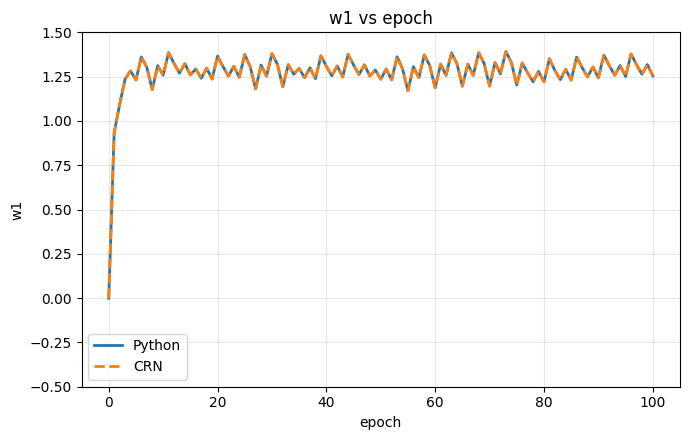

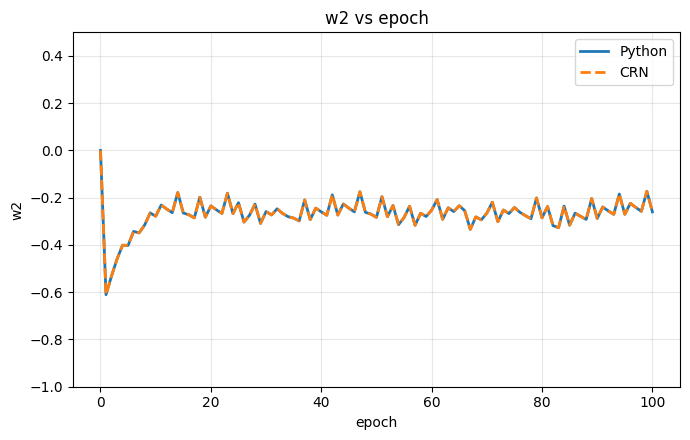

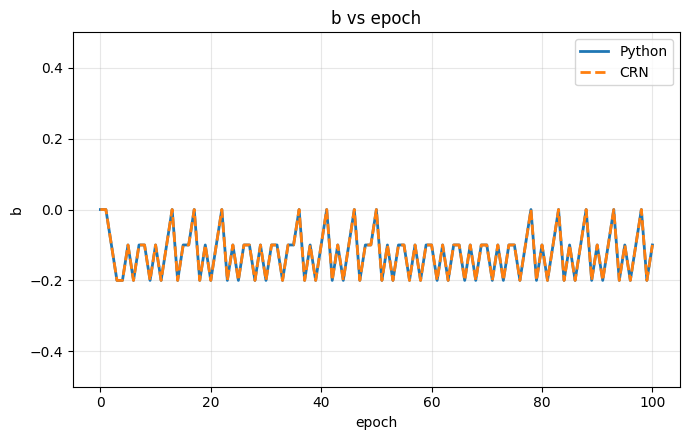

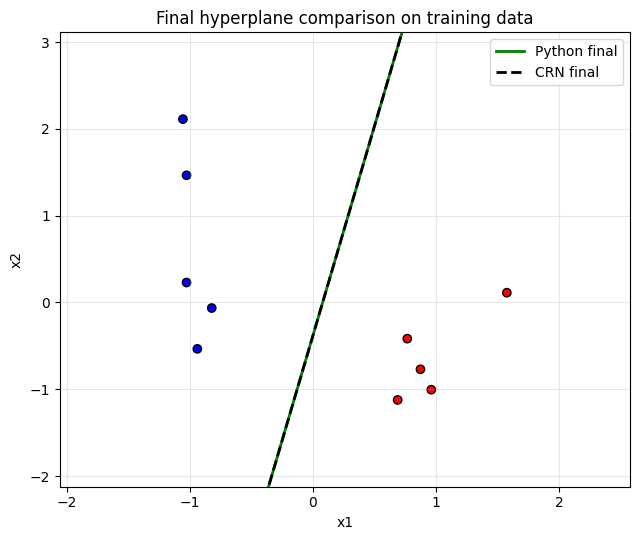

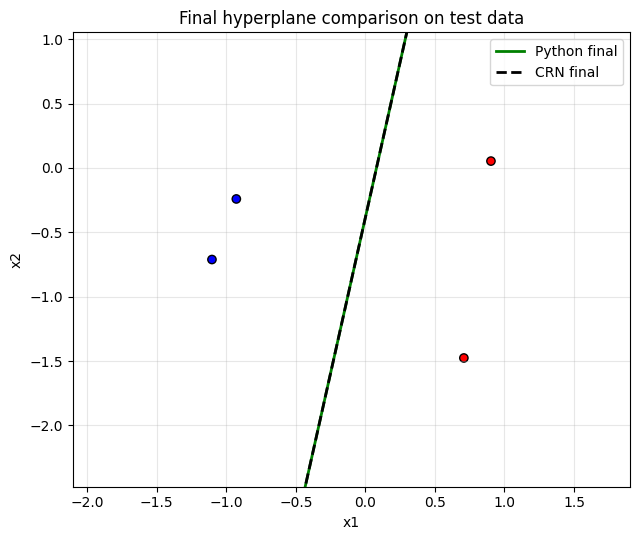

saved result figures to results/figures at dpi=400


In [12]:
import numpy as np
import matplotlib.pyplot as plt


def render_parallel_batch_results(
    W_py,
    b_py,
    W_crn,
    b_crn,
    X_trs,
    y_tr,
    X_tes,
    y_te,
    output_dir,
    dpi,
    save_figures=False,
):
    """Render the result figures shown at the end of the notebook.

    The function displays parameter evolution for ``w1``, ``w2``, and ``b``,
    together with the final separating hyperplanes on the training and test sets.
    When ``save_figures=True``, the same figures are written to ``output_dir``.
    """
    W_py = np.asarray(W_py, dtype=float)
    b_py = np.asarray(b_py, dtype=float)
    W_crn = np.asarray(W_crn, dtype=float)
    b_crn = np.asarray(b_crn, dtype=float)
    output_dir = Path(output_dir)
    if save_figures:
        output_dir.mkdir(parents=True, exist_ok=True)

    epochs = np.arange(W_py.shape[0], dtype=int)

    # Fixed y-axis limits are used only for the paper-style deterministic dataset so
    # the resulting figures remain visually comparable across runs.
    ylimits = {
        'w1 vs epoch' : [-0.5, 1.5],
        'w2 vs epoch' : [-1, 0.5],
        'b vs epoch' : [-0.5, 0.5]
    }

    def _plot_separator(ax, w, b, xlim, label, style):
        w = np.asarray(w, dtype=float)
        if abs(w[1]) < 1e-12:
            x0 = -b / (w[0] + 1e-12)
            ax.plot([x0, x0], [-1e6, 1e6], style, label=label, linewidth=2.0)
            return
        xs = np.linspace(xlim[0], xlim[1], 300)
        ys = -(w[0] * xs + b) / w[1]
        ax.plot(xs, ys, style, label=label, linewidth=2.0)

    def _make_evolution(py_values, crn_values, ylabel, title, filename):
        fig, ax = plt.subplots(figsize=(7.0, 4.5))
        ax.plot(epochs, py_values, label='Python', linewidth=2.0)
        ax.plot(epochs, crn_values, '--', label='CRN', linewidth=2.0)
        ax.set_xlabel('epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(alpha=0.3)
        if not USE_RANDOM:
            ylimit = ylimits[title]
            ax.set_ylim(ylimit[0], ylimit[1])
        ax.legend()
        fig.tight_layout()
        if save_figures:
            fig.savefig(output_dir / filename, dpi=dpi, bbox_inches='tight')
        plt.show()
        plt.close(fig)

    def _make_hyperplane(X, y, title, filename):
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
        xlim = (X[:, 0].min() - 1.0, X[:, 0].max() + 1.0)
        ylim = (X[:, 1].min() - 1.0, X[:, 1].max() + 1.0)
        _plot_separator(ax, W_py[-1], b_py[-1], xlim, 'Python final', 'g-')
        _plot_separator(ax, W_crn[-1], b_crn[-1], xlim, 'CRN final', 'k--')
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.grid(alpha=0.3)
        ax.legend()
        fig.tight_layout()
        if save_figures:
            fig.savefig(output_dir / filename, dpi=dpi, bbox_inches='tight')
        plt.show()
        plt.close(fig)
    
    _make_evolution(W_py[:, 0], W_crn[:, 0], 'w1', 'w1 vs epoch', 'w1_evolution.png')
    _make_evolution(W_py[:, 1], W_crn[:, 1], 'w2', 'w2 vs epoch', 'w2_evolution.png')
    _make_evolution(b_py, b_crn, 'b', 'b vs epoch', 'b_evolution.png')
    _make_hyperplane(X_trs, y_tr, 'Final hyperplane comparison on training data', 'hyperplane_train.png')
    _make_hyperplane(X_tes, y_te, 'Final hyperplane comparison on test data', 'hyperplane_test.png')

    if save_figures:
        print(f'saved result figures to {output_dir} at dpi={dpi}')


if all(name in globals() for name in ['W_py', 'b_py', 'W_crn', 'b_crn', 'X_trs', 'y_tr', 'X_tes', 'y_te']):
    render_parallel_batch_results(
        W_py,
        b_py,
        W_crn,
        b_crn,
        X_trs,
        y_tr,
        X_tes,
        y_te,
        output_dir=RESULT_FIGURES_DIR,
        dpi=RESULT_FIGURE_DPI,
        save_figures=SAVE_RESULT_FIGURES,
    )
